In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report

# Load the dataset
df = pd.read_csv("credit_card.csv")
print(f"Initial setup complete. Loaded {df.shape[0]} customer accounts.")

Initial setup complete. Loaded 8950 customer accounts.


In [2]:
# 1. Create a definitive copy to avoid any slice warnings
df_clean = df.drop_duplicates().copy()

# 2. Fix potential missing values using column medians or zero-fill safely
df_clean['CREDIT_LIMIT'] = df_clean['CREDIT_LIMIT'].fillna(df_clean['CREDIT_LIMIT'].median())
df_clean['MINIMUM_PAYMENTS'] = df_clean['MINIMUM_PAYMENTS'].fillna(0)

# 3. Clean format errors (ensure purchases are positive numbers)
if 'PURCHASES' in df_clean.columns:
    df_clean['PURCHASES'] = df_clean['PURCHASES'].abs()

# 4. Define our Banking Risk Flag target
df_clean['Risk_Flag'] = 0
high_risk_condition = (df_clean['BALANCE'] > (df_clean['CREDIT_LIMIT'] * 0.8)) & (df_clean['PAYMENTS'] < 200)
df_clean.loc[high_risk_condition, 'Risk_Flag'] = 1

print("Data cleaning and risk definition complete.")
print(df_clean['Risk_Flag'].value_counts())

Data cleaning and risk definition complete.
Risk_Flag
0    8858
1      92
Name: count, dtype: int64


In [3]:
# Select features that do not cause data leakage
features = ['INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT', 'MINIMUM_PAYMENTS']

X = df_clean[features]
y = df_clean['Risk_Flag']

# Split data into Train (80%) and Test (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the production model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Calculate the continuous risk probabilities across the whole dataset
df_clean['Risk_Probability'] = model.predict_proba(X)[:, 1]
print("Machine learning pipeline successfully calibrated.")

Machine learning pipeline successfully calibrated.


In [4]:
# Initialize optimization metrics
df_clean['Optimized_Limit'] = df_clean['CREDIT_LIMIT']
df_clean['Strategy_Action'] = 'Maintain Limit'

# Apply optimization rules
increase_rule = (df_clean['Risk_Probability'] < 0.15) & (df_clean['PURCHASES'] > 1000)
df_clean.loc[increase_rule, 'Optimized_Limit'] = df_clean['CREDIT_LIMIT'] * 1.30
df_clean.loc[increase_rule, 'Strategy_Action'] = 'Increase Limit (+30%)'

decrease_rule = (df_clean['Risk_Probability'] > 0.50)
df_clean.loc[decrease_rule, 'Optimized_Limit'] = df_clean['CREDIT_LIMIT'] * 0.50
df_clean.loc[decrease_rule, 'Strategy_Action'] = 'Decrease Limit (-50%)'

# Calculate financial impact metrics
capital_saved = (df_clean.loc[df_clean['Strategy_Action'].str.contains('Decrease'), 'CREDIT_LIMIT'] - 
                 df_clean.loc[df_clean['Strategy_Action'].str.contains('Decrease'), 'Optimized_Limit']).sum()

limit_expansion = (df_clean.loc[df_clean['Strategy_Action'].str.contains('Increase'), 'Optimized_Limit'] - 
                   df_clean.loc[df_clean['Strategy_Action'].str.contains('Increase'), 'CREDIT_LIMIT']).sum()
new_swipe_revenue = (limit_expansion * 0.15) * 0.02

# Print the formal executive report
print("====================================================")
print("          FINANCIAL IMPACT REPORT (ROI)             ")
print("====================================================")
print(f"🔒 Total Risk Capital Insulated:                  ${capital_saved:,.2f}")
print(f"💰 Projected New Annual Swipe Revenue Unlocked:    ${new_swipe_revenue:,.2f}")
print(f"📈 Total Quantified Portfolio Value Generated:   ${(capital_saved + new_swipe_revenue):,.2f}")
print("====================================================")
print("\n--- STRATEGY ACTION COHORT COUNTS ---")
print(df_clean['Strategy_Action'].value_counts())

# Export the final master production results to a clean CSV file
df_clean.to_csv("credit_card_optimized_results.csv", index=False)
print("\n🎉 Master production dataset successfully exported!")

          FINANCIAL IMPACT REPORT (ROI)             
🔒 Total Risk Capital Insulated:                  $78,175.00
💰 Projected New Annual Swipe Revenue Unlocked:    $13,661.05
📈 Total Quantified Portfolio Value Generated:   $91,836.05

--- STRATEGY ACTION COHORT COUNTS ---
Strategy_Action
Maintain Limit           6426
Increase Limit (+30%)    2445
Decrease Limit (-50%)      79
Name: count, dtype: int64

🎉 Master production dataset successfully exported!


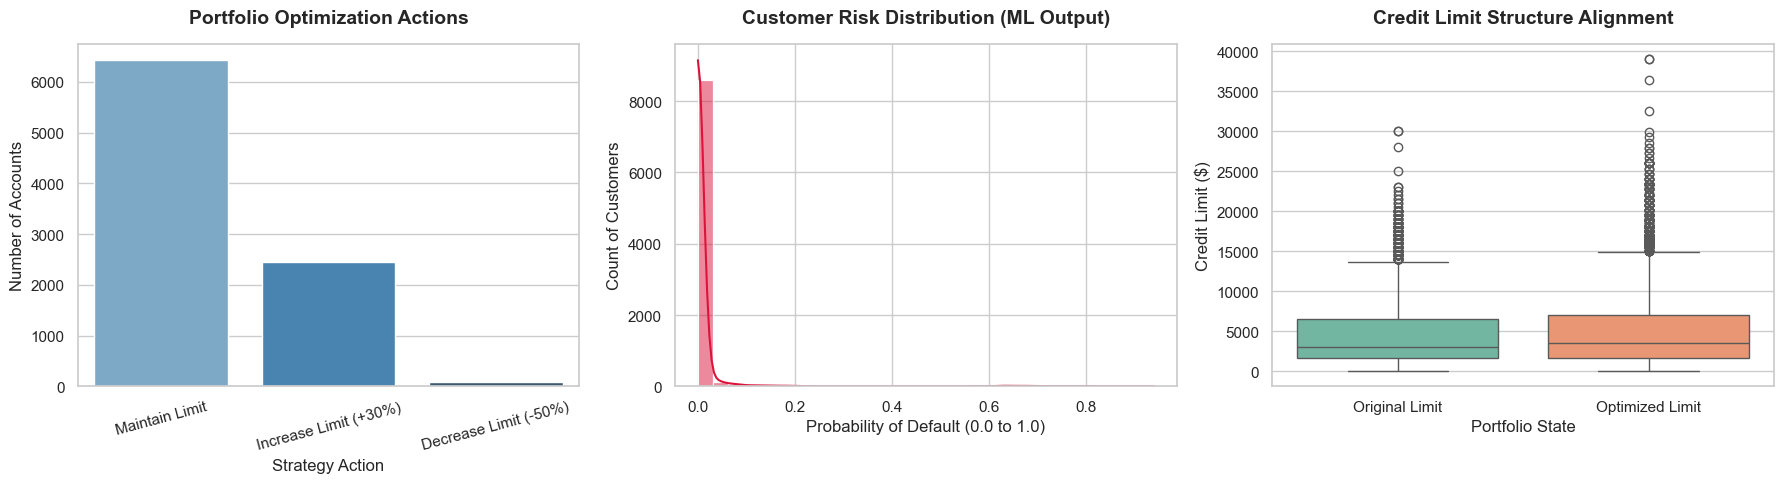

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a professional visual style for our charts
sns.set_theme(style="whitegrid")
plt.figure(figsize=(18, 5))

# --- CHART 1: The Strategy Breakdown (Bar Chart) ---
plt.subplot(1, 3, 1)
strategy_counts = df_clean['Strategy_Action'].value_counts()

# FIX: Added hue=strategy_counts.index and legend=False to silence the warning
sns.barplot(
    x=strategy_counts.index, 
    y=strategy_counts.values, 
    hue=strategy_counts.index, 
    palette="Blues_d", 
    legend=False
)
plt.title("Portfolio Optimization Actions", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Strategy Action", fontsize=12)
plt.ylabel("Number of Accounts", fontsize=12)
plt.xticks(rotation=15)

# --- CHART 2: Risk Profile Distribution (Histogram) ---
plt.subplot(1, 3, 2)
sns.histplot(data=df_clean, x='Risk_Probability', bins=30, kde=True, color="crimson")
plt.title("Customer Risk Distribution (ML Output)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Probability of Default (0.0 to 1.0)", fontsize=12)
plt.ylabel("Count of Customers", fontsize=12)

# --- CHART 3: Credit Limit Evolution (Box Plot) ---
plt.subplot(1, 3, 3)
limit_comparison = df_clean[['CREDIT_LIMIT', 'Optimized_Limit']].melt(var_name='Timeline', value_name='Limit_Amount')
limit_comparison['Timeline'] = limit_comparison['Timeline'].replace({'CREDIT_LIMIT': 'Original Limit', 'Optimized_Limit': 'Optimized Limit'})

# FIX: Added hue='Timeline' and legend=False to silence the warning
sns.boxplot(
    data=limit_comparison, 
    x='Timeline', 
    y='Limit_Amount', 
    hue='Timeline', 
    palette="Set2", 
    legend=False
)
plt.title("Credit Limit Structure Alignment", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Portfolio State", fontsize=12)
plt.ylabel("Credit Limit ($)", fontsize=12)

# Automatically adjust padding
plt.tight_layout()

# Render the dashboard
plt.show()

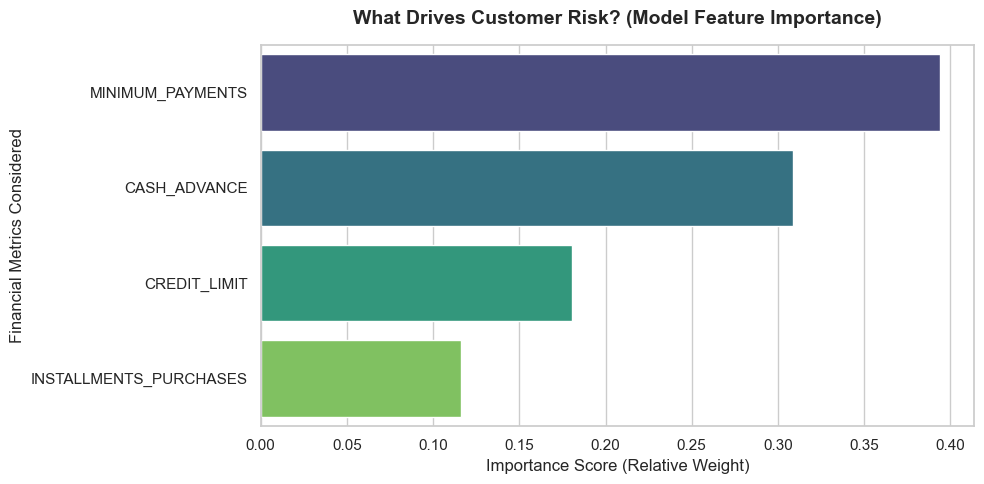

In [6]:
# 1. FIX: Changed 'real_model' to 'model' and 'challenging_features' to 'features'
importances = model.feature_importances_

# 2. Organize the data into a clean Pandas Series using the correct variable 'features'
feature_importance_df = pd.Series(importances, index=features).sort_values(ascending=False)

# 3. Render a clean, horizontal bar chart
plt.figure(figsize=(10, 5))
sns.barplot(
    x=feature_importance_df.values, 
    y=feature_importance_df.index, 
    hue=feature_importance_df.index, 
    palette="viridis", 
    legend=False
)

plt.title("What Drives Customer Risk? (Model Feature Importance)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Importance Score (Relative Weight)", fontsize=12)
plt.ylabel("Financial Metrics Considered", fontsize=12)
plt.tight_layout()
plt.show()

In [7]:
import sqlite3

# 1. Create an in-memory SQL database and establish a connection
conn = sqlite3.connect(':memory:')
cursor = conn.cursor()

# 2. Run the SQL table creation query
cursor.execute('''
CREATE TABLE credit_portfolio (
    cust_id TEXT PRIMARY KEY,
    balance REAL,
    purchases REAL,
    credit_limit REAL,
    risk_flag INTEGER,
    risk_probability REAL,
    optimized_limit REAL,
    strategy_action TEXT
)
''')

# 3. Stream your Python dataframe directly into the SQL table
df_clean[['CUST_ID', 'BALANCE', 'PURCHASES', 'CREDIT_LIMIT', 'Risk_Flag', 'Risk_Probability', 'Optimized_Limit', 'Strategy_Action']].to_sql('credit_portfolio', conn, if_exists='append', index=False)

# 4. Run your Enterprise Audit Query using pure SQL syntax!
audit_query = '''
SELECT 
    strategy_action AS portfolio_strategy,
    COUNT(cust_id) AS total_accounts,
    ROUND(AVG(risk_probability) * 100, 2) AS avg_risk_percentage,
    SUM(credit_limit) AS original_capital,
    SUM(optimized_limit) AS optimized_capital
FROM 
    credit_portfolio
GROUP BY 
    strategy_action;
'''

# Read and display the SQL query result right on your screen
sql_result = pd.read_sql_query(audit_query, conn)
sql_result

,portfolio_strategy,total_accounts,avg_risk_percentage,original_capital,optimized_capital
0,Decrease Limit (-50%),79,70.59,1.563500e+05,7.817500e+04
1,Increase Limit (+30%),2445,0.16,1.517894e+07,1.973263e+07
2,Maintain Limit,6426,0.51,2.488854e+07,2.488854e+07
